<a href="https://colab.research.google.com/github/NK-cloud-hub/testrepo/blob/main/Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score


In [ ]:
# 2. Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Save raw labels for later metrics
y_test_raw = y_test.copy()
y_train_raw = y_train.copy()


In [ ]:
# 3. Preprocessing for Dense models
num_pixels = X_train.shape[1] * X_train.shape[2]
X_train_dense = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') / 255
X_test_dense = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') / 255


In [ ]:
# 4. One-hot encode targets
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [ ]:
# 5. Baseline Dense Model
def build_baseline():
    model = Sequential()
    model.add(Dense(num_pixels, input_shape=(num_pixels,), activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_baseline = build_baseline()
model_baseline.fit(X_train_dense, y_train_cat, validation_data=(X_test_dense, y_test_cat), epochs=10, batch_size=200, verbose=2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 9s - 29ms/step - accuracy: 0.9206 - loss: 0.2773 - val_accuracy: 0.9601 - val_loss: 0.1337
Epoch 2/10
300/300 - 10s - 32ms/step - accuracy: 0.9677 - loss: 0.1114 - val_accuracy: 0.9713 - val_loss: 0.0980
Epoch 3/10
300/300 - 6s - 18ms/step - accuracy: 0.9793 - loss: 0.0713 - val_accuracy: 0.9752 - val_loss: 0.0793
Epoch 4/10
300/300 - 11s - 36ms/step - accuracy: 0.9855 - loss: 0.0511 - val_accuracy: 0.9775 - val_loss: 0.0697
Epoch 5/10
300/300 - 7s - 23ms/step - accuracy: 0.9897 - loss: 0.0368 - val_accuracy: 0.9803 - val_loss: 0.0630
Epoch 6/10
300/300 - 6s - 19ms/step - accuracy: 0.9930 - loss: 0.0275 - val_accuracy: 0.9795 - val_loss: 0.0623
Epoch 7/10
300/300 - 11s - 35ms/step - accuracy: 0.9950 - loss: 0.0197 - val_accuracy: 0.9814 - val_loss: 0.0592
Epoch 8/10
300/300 - 11s - 36ms/step - accuracy: 0.9969 - loss: 0.0147 - val_accuracy: 0.9815 - val_loss: 0.0589
Epoch 9/10
300/300 - 6s - 20ms/step - accuracy: 0.9977 - loss: 0.0112 - val_accuracy: 0.9810 - val_l

In [ ]:
# 6. Improved Dense Model
def build_improved_dense():
    model = Sequential()
    model.add(Dense(512, input_shape=(num_pixels,), activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_improved = build_improved_dense()
model_improved.fit(X_train_dense, y_train_cat, validation_data=(X_test_dense, y_test_cat), epochs=10, batch_size=200, verbose=2)


Epoch 1/10
300/300 - 8s - 25ms/step - accuracy: 0.9025 - loss: 0.3206 - val_accuracy: 0.9601 - val_loss: 0.1242
Epoch 2/10
300/300 - 7s - 23ms/step - accuracy: 0.9611 - loss: 0.1292 - val_accuracy: 0.9712 - val_loss: 0.0869
Epoch 3/10
300/300 - 6s - 19ms/step - accuracy: 0.9705 - loss: 0.0948 - val_accuracy: 0.9725 - val_loss: 0.0854
Epoch 4/10
300/300 - 7s - 23ms/step - accuracy: 0.9767 - loss: 0.0759 - val_accuracy: 0.9785 - val_loss: 0.0660
Epoch 5/10
300/300 - 6s - 20ms/step - accuracy: 0.9803 - loss: 0.0622 - val_accuracy: 0.9802 - val_loss: 0.0642
Epoch 6/10
300/300 - 10s - 33ms/step - accuracy: 0.9825 - loss: 0.0546 - val_accuracy: 0.9813 - val_loss: 0.0617
Epoch 7/10
300/300 - 11s - 38ms/step - accuracy: 0.9852 - loss: 0.0467 - val_accuracy: 0.9805 - val_loss: 0.0623
Epoch 8/10
300/300 - 10s - 34ms/step - accuracy: 0.9866 - loss: 0.0415 - val_accuracy: 0.9817 - val_loss: 0.0618
Epoch 9/10
300/300 - 9s - 30ms/step - accuracy: 0.9882 - loss: 0.0360 - val_accuracy: 0.9809 - val_lo

In [ ]:
# 7. CNN Model (requires 4D input)
X_train_cnn = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test_cnn = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

def build_cnn():
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn()
cnn.fit(X_train_cnn, y_train_cat, validation_data=(X_test_cnn, y_test_cat), epochs=10, batch_size=200, verbose=2)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 49s - 164ms/step - accuracy: 0.9076 - loss: 0.3053 - val_accuracy: 0.9797 - val_loss: 0.0666
Epoch 2/10
300/300 - 79s - 265ms/step - accuracy: 0.9741 - loss: 0.0863 - val_accuracy: 0.9865 - val_loss: 0.0401
Epoch 3/10
300/300 - 81s - 271ms/step - accuracy: 0.9805 - loss: 0.0634 - val_accuracy: 0.9893 - val_loss: 0.0331
Epoch 4/10
300/300 - 83s - 277ms/step - accuracy: 0.9852 - loss: 0.0499 - val_accuracy: 0.9909 - val_loss: 0.0277
Epoch 5/10
300/300 - 81s - 269ms/step - accuracy: 0.9872 - loss: 0.0428 - val_accuracy: 0.9913 - val_loss: 0.0256
Epoch 6/10
300/300 - 47s - 158ms/step - accuracy: 0.9885 - loss: 0.0382 - val_accuracy: 0.9920 - val_loss: 0.0262
Epoch 7/10
300/300 - 78s - 261ms/step - accuracy: 0.9898 - loss: 0.0326 - val_accuracy: 0.9919 - val_loss: 0.0247
Epoch 8/10
300/300 - 84s - 280ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9918 - val_loss: 0.0225
Epoch 9/10
300/300 - 80s - 268ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accuracy: 

In [ ]:

# 8. Evaluation Function
def evaluate_model(name, model, X, y_true_cat, y_true_raw):
    y_probs = model.predict(X)
    y_preds = np.argmax(y_probs, axis=1)
    y_true = y_true_raw

    accuracy = np.mean(y_preds == y_true)
    precision = precision_score(y_true, y_preds, average='macro')
    recall = recall_score(y_true, y_preds, average='macro')
    f1 = f1_score(y_true, y_preds, average='macro')

    print(f"\n {name} Model Evaluation:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_preds))

    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

 Baseline Dense Model Evaluation:
Accuracy : 0.9813
Precision: 0.9813
Recall   : 0.9811
F1 Score : 0.9812

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



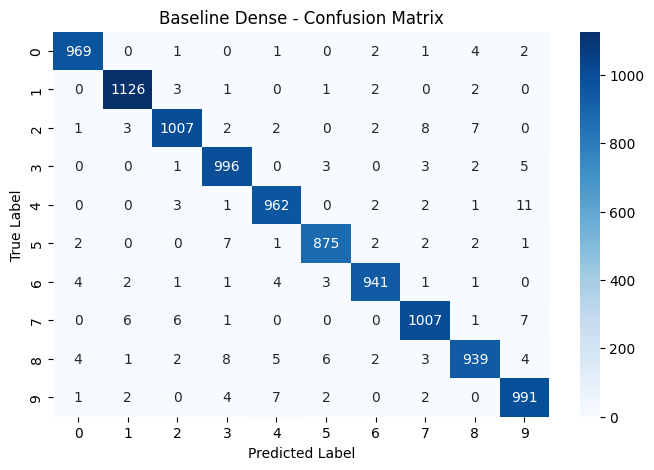

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

 Improved Dense Model Evaluation:
Accuracy : 0.9800
Precision: 0.9801
Recall   : 0.9797
F1 Score : 0.9799

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



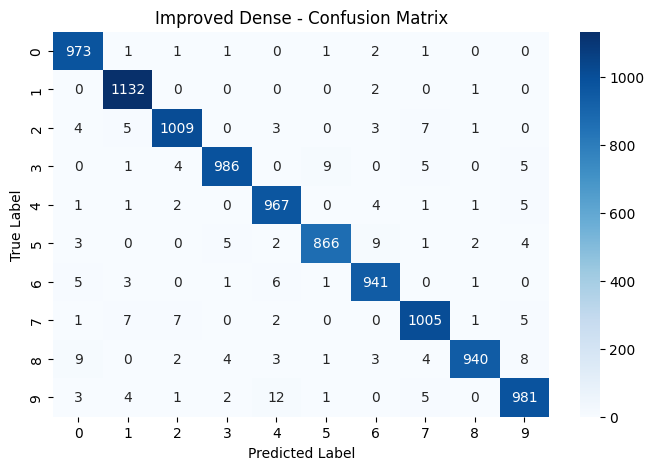

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step

 CNN Model Evaluation:
Accuracy : 0.9921
Precision: 0.9921
Recall   : 0.9919
F1 Score : 0.9920

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



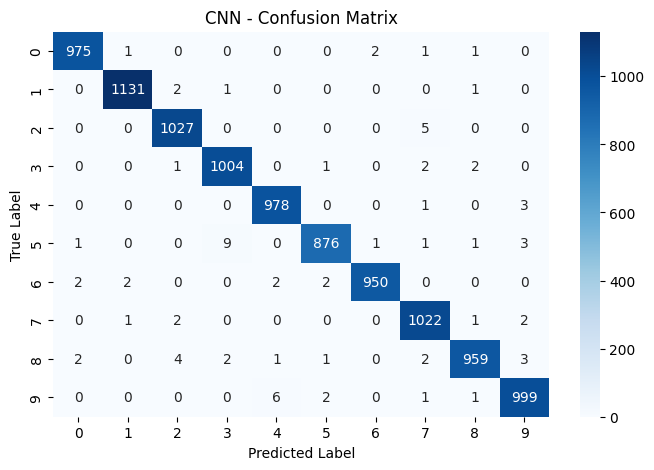

In [ ]:
# 9. Run Evaluation for All Models
evaluate_model("Baseline Dense", model_baseline, X_test_dense, y_test_cat, y_test_raw)
evaluate_model("Improved Dense", model_improved, X_test_dense, y_test_cat, y_test_raw)
evaluate_model("CNN", cnn, X_test_cnn, y_test_cat, y_test_raw)